In [1]:
import multivelo as mv

In [2]:
import os
import scipy
import numpy as np
import pandas as pd

import anndata
import scanpy as sc
import scvelo as scv
import matplotlib.pyplot as plt

In [3]:
scv.settings.verbosity = 3
scv.settings.presenter_view = True
scv.set_figure_params('scvelo')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
np.set_printoptions(suppress=True)

In [4]:
suff = 'cl13/'
os.makedirs('processed_data/'+suff, exist_ok = True)
os.makedirs('modeling_results/'+suff, exist_ok = True)

# Preprocessing

In [5]:
to_filt = ['Cd8 dys', 'Cd8 eff', 'Cd8 prog']

## ATAC

In [6]:
adata_atac_raw = sc.read('data/full_LCMV_T_cell_dataset/summits_clean.h5ad')

In [7]:
clone = adata_atac_raw.obs['version']

In [8]:
adata_atac_raw.X = adata_atac_raw.layers['raw']

In [9]:
cells_to_pick = adata_atac_raw.obs_names[adata_atac_raw.obs['final annotation'].isin(to_filt)*(clone == 'mult_cl13')]

In [10]:
adata_atac_raw = adata_atac_raw[cells_to_pick,:]

In [11]:
adata_atac_raw_full = adata_atac_raw.copy()

In [12]:
sc.pp.filter_genes(adata_atac_raw, min_cells=0.01*adata_atac_raw.shape[0])

In [13]:
adata_atac_raw.layers['poisson_corrected'] = np.array(np.ceil(adata_atac_raw.layers['raw'].todense()/2))

In [14]:
adata_atac_raw.X = np.array(adata_atac_raw.layers["poisson_corrected"].copy())
sc.experimental.pp.normalize_pearson_residuals(adata_atac_raw, theta=1)
adata_atac_raw.layers["pearson"] = adata_atac_raw.X.copy()

In [15]:
adata_atac_raw.shape

(2594, 251992)

In [16]:
adata_atac_raw_pre = adata_atac_raw.copy()

In [17]:
adata_atac_raw_pre.write('processed_data/'+suff+'/adata_atac_raw_pre.h5ad')

## Reading in processed RNA

In [18]:
adata_rna = sc.read_h5ad('data/full_LCMV_T_cell_dataset/rna_cleaned.h5ad')

In [19]:
spl = {}
unspl = {}
for typ in ['cl13']:
    spl[typ] = pd.read_csv('data/final_'+typ+'_exons.csv', index_col = [0])
    unspl[typ] = pd.read_csv('data/final_'+typ+'_introns.csv', index_col = [0])
spl = pd.concat(spl)
unspl = pd.concat(unspl)
spl.index.names = ['type', 'cell']
unspl.index.names = ['type', 'cell']
spl['cell_rna'] = [x+'.mult_'+k for (x,k) in zip(spl.index.get_level_values('cell'), spl.index.get_level_values('type'))]
spl = spl.set_index('cell_rna', append = True)
unspl['cell_rna'] = [x+'.mult_'+k for (x,k) in zip(unspl.index.get_level_values('cell'), unspl.index.get_level_values('type'))]
unspl = unspl.set_index('cell_rna', append = True)
spl = spl.droplevel([0,1])
unspl = unspl.droplevel([0,1])

In [20]:
adata_rna = adata_rna[cells_to_pick,:]


In [21]:
adata_rna.X = adata_rna.layers['raw_counts'].copy()

In [22]:
adata_rna.layers['spliced'] = spl.loc[adata_rna.obs.index,adata_rna.var_names].values.copy()
adata_rna.layers['unspliced'] = unspl.loc[adata_rna.obs.index,adata_rna.var_names].values.copy()


In [23]:
adata_rna.X = adata_rna.layers['raw_counts'].copy()
scv.pp.filter_and_normalize(adata_rna, min_shared_counts = 30, n_top_genes = 1500)

Filtered out 9466 genes that are detected 30 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 1500 highly variable genes.
Logarithmized X.


/mnt/home/mavdeeva/Software/VENVs/python3.8-env/lib/python3.8/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


In [24]:
adata_rna.layers['log1p'] = adata_rna.X.copy()

In [25]:
adata_rna.X = adata_rna.layers['theta_10'].copy()

In [26]:
met = 'cosine'
n_pcs = 50
n_neigh = 50
res = 1.5

In [27]:
sc.pp.pca(adata_rna, n_pcs, use_highly_variable = True, random_state = 50)
sc.pp.neighbors(adata_rna, n_neighbors=n_neigh, n_pcs=n_pcs, 
                            metric = met, 
                knn=True, random_state = 50)
sc.tl.leiden(adata_rna, resolution = res, random_state = 50)


In [28]:
scv.pp.moments(adata_rna, n_pcs=n_pcs, n_neighbors=n_neigh)

computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


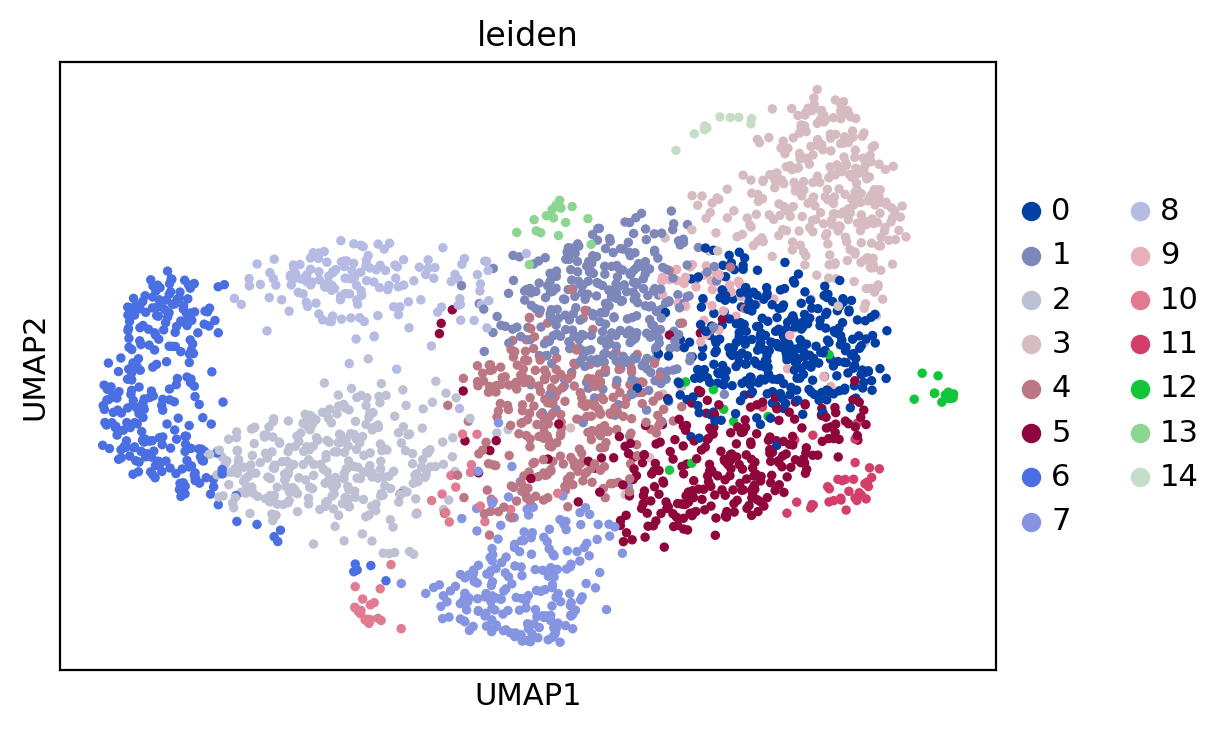

In [29]:
sc.tl.umap(adata_rna, random_state = 50)
sc.pl.umap(adata_rna, color = 'leiden')

In [30]:
adata_rna.obs['celltype'] = adata_rna.obs['final annotation']

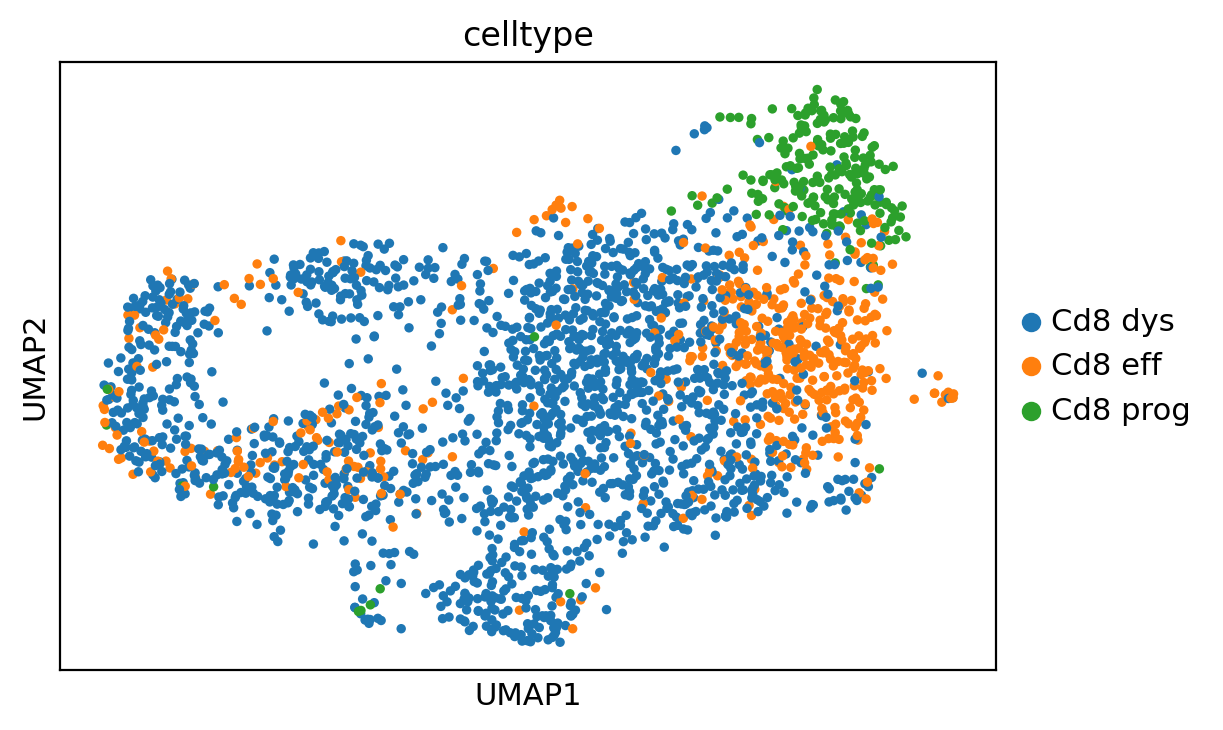

In [31]:
sc.pl.umap(adata_rna, color = 'celltype')

In [32]:
adata_rna_pre = adata_rna.copy()

In [33]:
adata_rna_pre.write('processed_data/'+suff+'/adata_rna_pre.h5ad')

### subset peaks to ones that map to an RNA gene

In [34]:
adata_atac_raw = adata_atac_raw_pre.copy()

In [35]:
peak_annotation = pd.read_csv('data/full_LCMV_T_cell_dataset/nearest_genes_to_summits.distances.csv', index_col = [0,1])#.droplevel(0)
peak_annotation = peak_annotation.reset_index().set_index('name')
peak_annotation = peak_annotation.loc[adata_atac_raw.var_names,:]
peak_annotation_cop = peak_annotation.copy()



In [36]:
len(peak_annotation['gene'].unique())

24419

In [37]:
# leave only peaks that map to one of the genes in RNA matrix
rel_peaks = adata_atac_raw.var_names[peak_annotation['gene'].isin(adata_rna.var_names).values]



In [38]:
len(rel_peaks)

34825

In [39]:
# not all genes from RNA are present in the annotation
len(np.unique(peak_annotation_cop.loc[rel_peaks]['gene']))

1458

In [40]:
adata_atac_raw = adata_atac_raw[:, rel_peaks]

In [41]:
rel_genes = np.unique(peak_annotation[peak_annotation['gene'].isin(adata_rna.var_names).values]['gene'])

## MultiVelo preprocessing

In [42]:
cl = 'cl13'
adata_atac = sc.read_10x_h5('data/outs/'+cl+'_filtered_feature_bc_matrix.h5',
                                     gex_only=False)
adata_atac = adata_atac[:,adata_atac.var['feature_types'] == "Peaks"]

In [43]:
adata_atac = mv.aggregate_peaks_10x(adata_atac, 
                                    'data/outs/'+cl+'_atac_peak_annotation.tsv', 
                                'data/outs/'+cl+'_feature_linkage.bedpe', 
                                    verbose=True)

CellRanger ARC identified as 1.0.0
Found 17022 genes with promoter peaks


/mnt/home/mavdeeva/Software/VENVs/python3.8-env/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:503: DeprecationWarning: The `ipykernel.comm.Comm` class has been deprecated. Please use the `comm` module instead.For creating comms, use the function `from comm import create_comm`.
  self.comm = Comm(**args)


  0%|          | 0/17022 [00:00<?, ?it/s]

In [44]:
adata_atac.shape

(9584, 17018)

In [45]:
#filter cells to only relevant dataset
adata_atac = adata_atac[[x.split('.')[0] for x in cells_to_pick], :]#adata_rna.var_names]

In [46]:
adata_atac.obs_names = cells_to_pick

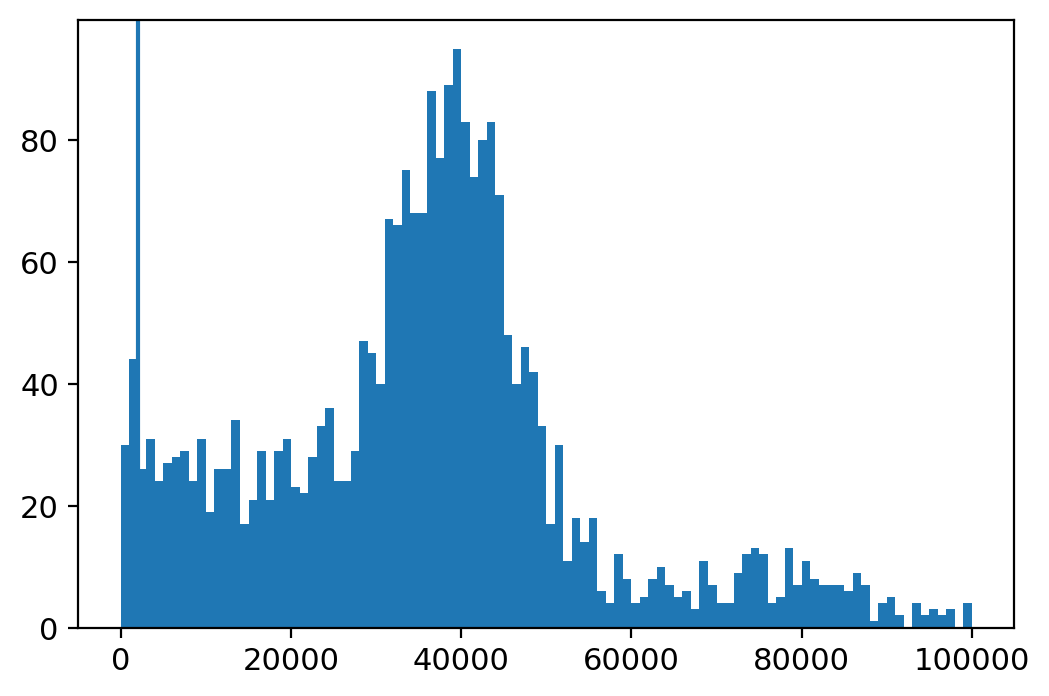

In [47]:
# Let's examine the total count distribution and remove outliers.
plt.hist(adata_atac.X.sum(1), bins=100, range=(0, 100000));
plt.axvline(2000)

In [48]:
sc.pp.filter_cells(adata_atac, min_counts=2000)

In [49]:
mv.tfidf_norm(adata_atac)

In [50]:
adata_atac.shape

(2520, 17018)

## Shared cells and features between RNA and ATAC

In [51]:
adata_rna = adata_rna_pre.copy()

In [52]:
adata_rna.shape, adata_atac.shape, adata_atac_raw.shape

((2594, 1500), (2520, 17018), (2594, 34825))

In [53]:
shared_cells = pd.Index(np.intersect1d(np.intersect1d(adata_rna.obs_names, adata_atac.obs_names), adata_atac_raw.obs_names))
shared_genes_atac = pd.Index(np.intersect1d(adata_rna.var_names, adata_atac.var_names))
shared_genes_atac_raw = pd.Index(np.intersect1d(adata_rna.var_names, rel_genes))
print('# cells shared between processed RNA and raw and multivelo filtered ATAC matrices: ',len(shared_cells))
print('# genes shared between RNA var_names and multivelo aggregated ATAC var_names', len(shared_genes_atac))
print('# genes shared between RNA var_names and the genes to which our ATAC peaks map', len(shared_genes_atac_raw))

# cells shared between processed RNA and raw and multivelo filtered ATAC matrices:  2520
# genes shared between RNA var_names and multivelo aggregated ATAC var_names 1479
# genes shared between RNA var_names and the genes to which our ATAC peaks map 1458


In [54]:
#mapping somewhere
mapped_genes = np.unique(np.unique(peak_annotation_cop['gene'].dropna()))
#present in rna
rna_genes = adata_rna.var_names
#present in adata_atac
aggr_genes = adata_atac.var_names
# #present in adata_atac_raw
atac_raw_genes = np.unique(peak_annotation_cop.loc[adata_atac_raw.var_names]['gene'])


In [55]:
shared_genes_total = mapped_genes
shared_genes_total = np.intersect1d(shared_genes_total, rna_genes)
shared_genes_total = np.intersect1d(shared_genes_total, aggr_genes)
shared_genes_total = np.intersect1d(shared_genes_total, atac_raw_genes)

In [56]:
print('# genes shared between both methods: ', len(shared_genes_total))

# genes shared between both methods:  1439


In [57]:
# #leave only corresponding peaks
rel_peaks_total = adata_atac_raw.var_names[peak_annotation_cop.loc[adata_atac_raw.var_names,:]['gene'].isin(shared_genes_total).values]

In [58]:
len(rel_peaks_total)

34451

In [59]:
adata_rna_atac_total = adata_rna[shared_cells, shared_genes_total]
adata_atac_total = adata_atac[shared_cells, shared_genes_total]
adata_atac_raw_total = adata_atac_raw[shared_cells, rel_peaks_total]

In [60]:
adata_rna = adata_rna_atac_total#.copy()

In [61]:
adata_atac = adata_atac_total
adata_atac_raw = adata_atac_raw_total

# Reprocess RNA

In [62]:
met = 'cosine'

In [63]:
sc.pp.pca(adata_rna, n_pcs,random_state = 0)
sc.pp.neighbors(adata_rna, n_neighbors=n_neigh, n_pcs=n_pcs, 
                            metric = met, 
                knn=True, random_state = 0)
sc.tl.leiden(adata_rna, resolution = res, random_state = 0)
scv.pp.moments(adata_rna, n_pcs=n_pcs, n_neighbors=n_neigh)

computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [64]:
sc.tl.umap(adata_rna, random_state = 0)

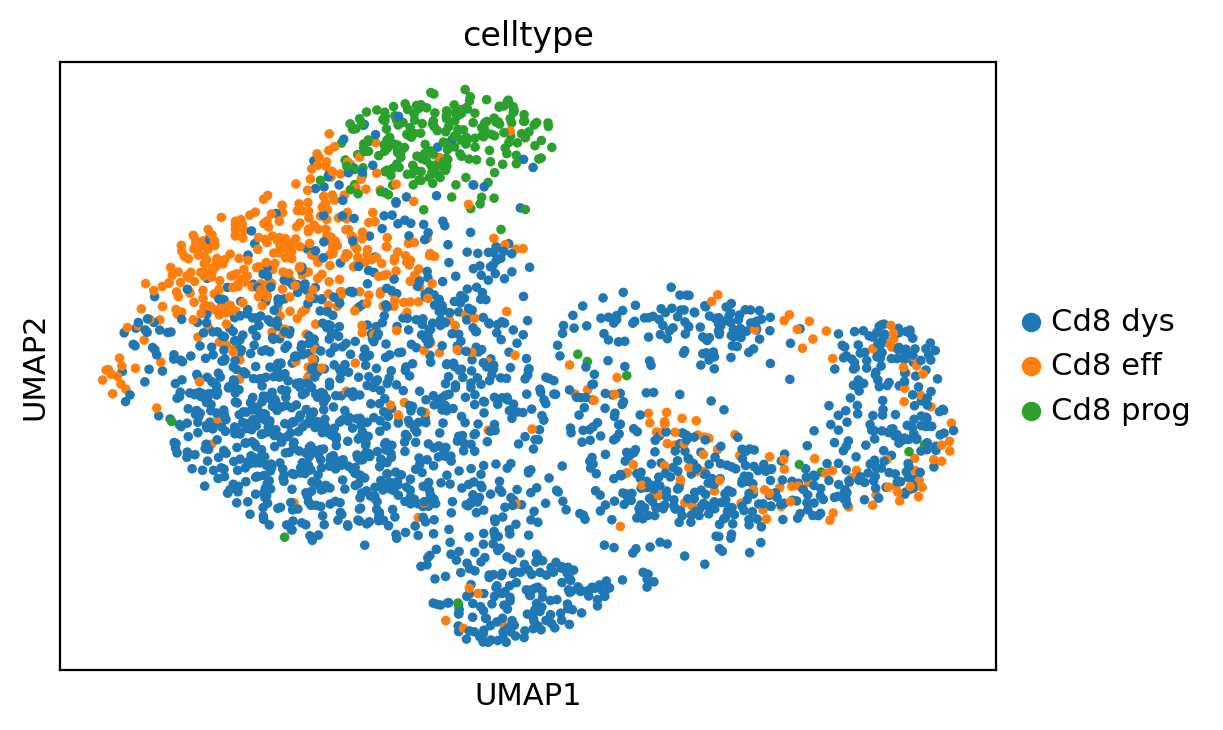

In [65]:
sc.pl.umap(adata_rna, color = 'celltype')

# Smooth ATAC

In [66]:
from auxiliary import *
adata_rna.var['highly_variable'] = True
nn_idx, nn_dist = gen_wnn(adata_rna, adata_atac, [n_pcs,n_pcs], n_neigh)

Orig w/ prints v4
Computing KNN distance matrices using default Scanpy implementation
Adata:
AnnData object with n_obs × n_vars = 2520 × 1439
    obs: 'type', 'n_genes', 'n_genes_by_counts', 'total_counts', 'atac_annotation', 'leiden', 'velocity', 'final annotation', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'celltype'
    var: 'other_name', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'atac_annotation_colors', 'final annotation', 'final annotation_colors', 'leiden', 'neighbors', 'pca', 'type_colors', 'umap', 'velocity_colors', 'log1p', 'celltype_colors', '1', '2', '1_200', '2_200'
    obsm: 'X_umap', 'X_umap_atac', 'X_umap_rna', 'X_rna_pca', 'X_adt_lsi', 'X_rna_pca_norm', 'X_adt_lsi_norm'
    varm: 'PCs'
    layers: 'raw_counts', 'theta_10', 'spliced', 'unspliced', 'log1p', 'Ms', 'Mu'
    obsp: 'connectivities', 'distances', '1_distances', '1_connectivities', '2_distances', '2_connectivities', '1_200_dist

In [67]:
import os
os.makedirs('seurat_wnn/'+suff, exist_ok = True)

In [68]:
np.savetxt('seurat_wnn/'+suff+'nn_idx.txt', nn_idx, delimiter=',')
np.savetxt('seurat_wnn/'+suff+'nn_dist.txt', nn_dist, delimiter=',')


In [69]:
mv.knn_smooth_chrom(adata_atac, nn_idx, nn_dist)

In [70]:
adata_atac.obsm['X_umap'] = adata_rna.obsm['X_umap']
adata_atac_raw.obsm['X_umap'] = adata_rna.obsm['X_umap']

# Write out all data

In [71]:
adata_atac_raw.write("processed_data/"+suff+"/adata_atac_raw.h5ad")

In [72]:
adata_atac.write("processed_data/"+suff+"/adata_atac.h5ad")

In [73]:
adata_rna.write("processed_data/"+suff+"/adata_rna.h5ad")